
<p style="text-align: center;">ЛАБОРАТОРНАЯ №2</p>

<p style="text-align: center;">СТРАТЕГИИ ТЕОРИИ СТАТИСТИЧЕСКОГО РАСПОЗНАВАНИЯ ОБРАЗОВ</p>


- **Вариант: №3** 
- **Выполнили: Богачев Матвей и Чумаков Иван**
- **Группа 6511**

## Исходные данные 
1. 2 файла, содержащих  наборы  двумерных  нормально  распределенных векторов  признаков  для ситуации  равных  корреляционных матриц; параметры этих законов распределения.

2. 3 Файла содержащих  наборы  двумерных  нормально  распределенных векторов признаков для ситуации **неравных** корреляционных матриц; параметры этих законов распределения

# Задания: 
1. Построить  байесовскую  решающую  границу  между  классами $\Omega_0$
 и $\Omega_1$  двумерных нормально распределенных векторов признаков  для  случая  равных  корреляционных  матриц  и  равных априорных вероятностей  и изобразить ее графически. Вычислить вероятности ошибочной классификации и суммарную вероятность ошибочной классификации в этом случае. 
2. Построить  минимаксный  классификатор  и  классификатор 
Неймана-Пирсона  для  вероятности  ошибки  первого  рода $p^*_0 = 0.05$ для  двух  классов $\Omega_0$ и $\Omega_1$ двумерных  нормально распределенных  векторов признаков  в случае  равных  корреляционных матриц. Изобразить решающие границы полученных классификаторов графически. 
3. Построить байесовскую решающую границу между классами $\Omega_0$ $\Omega_1$  $\Omega_2$, двумерных нормально распределенных векторов признаков для неравных корреляционных матриц и равных априорных вероятностей. Изобразить полученные решающие границы графически. Для любых двух классов оценить экспериментально  вероятности  ошибочной  классификации в этом случае и определить относительную погрешность полученных оценок для заданного объема обучающей выборки N.  Определить объем обучающей выборки, обеспечивающий получение  оценок  вероятностей  ошибочной  классификации с погрешностью не более 5%. 
4. Построить  байесовскую  разделяющую  границу  между  классами $\Omega_0$  и $\Omega_1$  двумерных бинарных векторов признаков. Вычислить  вероятности  ошибочной  классификации  аналитически и оценить их экспериментально.

In [7]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from typing import Tuple

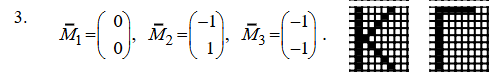

In [8]:
def get_mean(X: np.ndarray, N: int) -> np.ndarray:
    return np.sum(X, axis=0) / N

def get_var(X: np.ndarray, N: int) -> np.ndarray:
    variances = []
    for row in X.transpose():
        mean = sum(row) / N
        var = sum((x - mean) ** 2 for x in row) / (N - 1)
        variances.append(var)

    return np.array(variances)

def get_cov(X: np.ndarray) -> np.ndarray:
    X1 = X.transpose()
    num_rows, num_cols = X1.shape
    
    means = np.array([sum(X1[i]) / num_cols for i in range(num_rows)])
    
    cov_matrix = np.zeros((num_rows, num_rows))
    
    for i in range(num_rows):
        for j in range(num_rows):
            cov = sum((X1[i, k] - means[i]) * (X1[j, k] - means[j]) for k in range(num_cols)) / (num_cols - 1)
            cov_matrix[i, j] = cov

    return np.array(cov_matrix)

# def get_dist_Mahalanobis(M1: np.ndarray, M2: np.ndarray, B: np.ndarray) -> np.ndarray:
#     return np.dot(np.dot((M1 - M2).T, np.linalg.inv(B)), (M1 - M2))

def get_dist_Mahalanobis(M1: np.ndarray, M2: np.ndarray, B1: np.ndarray, B2: np.ndarray | None = None) -> np.ndarray:
    if B2 is None:
        B = B1
    else:
        B = (B1 + B2) / 2

    return np.dot(np.dot((M1 - M2).T, np.linalg.inv(B)), (M1 - M2))

def get_dist_Bhattacharyya(M1: np.ndarray, M2: np.ndarray, B1: np.ndarray, B2: np.ndarray) -> np.ndarray:
    B = (B1 + B2) / 2
    
    return 0.25 * np.dot(np.dot((M1 - M2).T, np.linalg.inv(B)), (M1 - M2)) + \
           0.5 * np.log(np.linalg.det(B) / np.sqrt(np.linalg.det(B1) * np.linalg.det(B2)))


In [9]:
# Параметры 
M1 = np.array([[0], 
               [0]])

M2 = np.array([[-1], 
               [1]])

M3 = np.array([[-1], 
               [-1]])

B1 = np.array([[0.2, 0.1],
               [0.1, 0.3]])

B2 = np.array([[0.3, 0.1],
               [0.1, 0.3]])

B3 = np.array([[0.3, -0.1],
               [-0.1, 0.2]])

X1_equal = np.load("data/Equal_cov/X1_equal.npy")
X2_equal = np.load("data/Equal_cov/X1_equal.npy")

X1_unequal = np.load("data/Unequal/X1_unequal.npy")
X2_unequal = np.load("data/Unequal/X1_unequal.npy")
X3_unequal = np.load("data/Unequal/X1_unequal.npy")

n = 200


In [10]:
meanX1_equal = get_mean(X1_equal, n)
meanX2_equal = get_mean(X2_equal, n)

varX1_equal = get_var(X1_equal, n)
varX2_equal = get_var(X2_equal, n)  

covX1_equal = get_cov(X1_equal) 
covX2_equal = get_cov(X2_equal) 


meanX1_unequal = get_mean(X1_unequal, n)
meanX2_unequal = get_mean(X2_unequal, n)
meanX3_unequal = get_mean(X3_unequal, n)

varX1_unequal = get_var(X1_unequal, n)
varX2_unequal = get_var(X2_unequal, n)
varX3_unequal = get_var(X3_unequal, n)

covX1_unequal = get_cov(X1_unequal) 
covX2_unequal = get_cov(X2_unequal) 
covX3_unequal = get_cov(X3_unequal) 

In [11]:
def Bayes_Classificator(M1: np.ndarray, M2: np.ndarray, 
                        B: np.ndarray, min: float, max: float, 
                        prob1: float, prob2: float) -> Tuple[np.ndarray, np.ndarray]:
    x = np.linspace(min, max, 200)

    B_inv = np.linalg.inv(B)
    a = np.dot((M1 - M2).T,  B_inv)
    b = -0.5 * np.dot(np.dot((M1 + M2).T, B_inv), (M1 - M2)) + np.log(prob1 / prob2)

    y = (-a[0] * x - b) / a[1]

    return x, y

def Min_Max_Classificator(M1: np.ndarray, M2: np.ndarray, 
                        B: np.ndarray, min: float, max: float, 
                        lambda1: float) -> Tuple[np.ndarray, np.ndarray]:
    x = np.linspace(min, max, 200)

    B_inv = np.linalg.inv(B)
    a = np.dot((M1 - M2).T,  B_inv)
    b = -0.5 * np.dot(np.dot((M1 + M2).T, B_inv), (M1 - M2)) + np.log(lambda1)

    y = (-a[0] * x - b) / a[1]

    return x, y

def Neyman_Pearson_Classificator(M1: np.ndarray, M2: np.ndarray, 
                        B: np.ndarray, min: float, max: float, 
                        p0: float, dist: float) -> Tuple[np.ndarray, np.ndarray]:
    x = np.linspace(min, max, 200)

    lambda_ln = -0.5 * dist + np.sqrt(dist) * norm.ppf(1 - p0)

    B_inv = np.linalg.inv(B)
    a = np.dot((M1 - M2).T,  B_inv)
    b = -0.5 * np.dot(np.dot((M1 + M2).T, B_inv), (M1 - M2)) + lambda_ln

    y = (-a[0] * x - b) / a[1]

    return x, y

def compute_prob_errors(dist: float, prob1: float, prob2: float) -> Tuple[float, float, float]:
    lambda1 = np.log(prob1 / prob2)

    err_I = float(1 - norm.cdf((lambda1 + 0.5 * dist) / np.sqrt(dist)))
    err_II = float(norm.cdf((lambda1 - 0.5 * dist) / np.sqrt(dist)))
    err = prob1 * err_I + prob2 * err_II

    return err_I, err_II, err

# Задание 1
Построить  байесовскую  решающую  границу  между  классами $\Omega_0$ и $\Omega_1$  двумерных нормально распределенных векторов признаков  для  случая  равных  корреляционных  матриц  и  равных априорных вероятностей  и изобразить ее графически. Вычислить вероятности ошибочной классификации и суммарную вероятность ошибочной классификации в этом случае.

In [12]:
def Bayes_Classificator(M1: np.ndarray, M2: np.ndarray, 
                        B: np.ndarray, min: float, max: float, 
                        prob1: float, prob2: float) -> Tuple[np.ndarray, np.ndarray]:
    x = np.linspace(min, max, 200)

    B_inv = np.linalg.inv(B)
    a = np.dot((M1 - M2).T,  B_inv)
    b = -0.5 * np.dot(np.dot((M1 + M2).T, B_inv), (M1 - M2)) + np.log(prob1 / prob2)

    y = (-a[0] * x - b) / a[1]

    return x, y

def Min_Max_Classificator(M1: np.ndarray, M2: np.ndarray, 
                        B: np.ndarray, min: float, max: float, 
                        lambda1: float) -> Tuple[np.ndarray, np.ndarray]:
    x = np.linspace(min, max, 200)

    B_inv = np.linalg.inv(B)
    a = np.dot((M1 - M2).T,  B_inv)
    b = -0.5 * np.dot(np.dot((M1 + M2).T, B_inv), (M1 - M2)) + np.log(lambda1)

    y = (-a[0] * x - b) / a[1]

    return x, y

def Neyman_Pearson_Classificator(M1: np.ndarray, M2: np.ndarray, 
                        B: np.ndarray, min: float, max: float, 
                        p0: float, dist: float) -> Tuple[np.ndarray, np.ndarray]:
    x = np.linspace(min, max, 200)

    lambda_ln = -0.5 * dist + np.sqrt(dist) * norm.ppf(1 - p0)

    B_inv = np.linalg.inv(B)
    a = np.dot((M1 - M2).T,  B_inv)
    b = -0.5 * np.dot(np.dot((M1 + M2).T, B_inv), (M1 - M2)) + lambda_ln

    y = (-a[0] * x - b) / a[1]

    return x, y

def compute_prob_errors(dist: float, prob1: float, prob2: float) -> Tuple[float, float, float]:
    lambda1 = np.log(prob1 / prob2)

    err_I = float(1 - norm.cdf((lambda1 + 0.5 * dist) / np.sqrt(dist)))
    err_II = float(norm.cdf((lambda1 - 0.5 * dist) / np.sqrt(dist)))
    err = prob1 * err_I + prob2 * err_II

    return err_I, err_II, err

# Задание 2. 
Построить  минимаксный  классификатор  и  классификатор Неймана-Пирсона  для  вероятности  ошибки  первого  рода $p^*_0 = 0 0.05$ для  двух  классов $\Omega_0$ и $\Omega_1$ двумерных  нормально распределенных  векторов признаков  в случае  равных  корреляционных матриц. Изобразить решающие границы полученных классификаторов графически.

# Задание 3. 
Построить байесовскую решающую границу между классами $\Omega_0$ $\Omega_1$  $\Omega_2$, двумерных нормально распределенных векторов признаков для неравных корреляционных матриц и равных априорных вероятностей. Изобразить полученные решающие границы графически. Для любых двух классов оценить экспериментально  вероятности  ошибочной  классификации в этом случае и определить относительную погрешность полученных оценок для заданного объема обучающей выборки N.  Определить объем обучающей выборки, обеспечивающий получение  оценок  вероятностей  ошибочной  классификации с погрешностью не более 5%.

# Задание 4. 
Построить  байесовскую  разделяющую  границу  между  классами $\Omega_0$  и $\Omega_1$  двумерных бинарных векторов признаков. Вычислить  вероятности  ошибочной  классификации  аналитически и оценить их экспериментально.